# 09 - Manager Full Walkthrough

> **Objetivo:** oferecer uma visão executiva-técnica completa do projeto de antecipação de alerta crítico (Don't Go), pronta para leitura sem terminal.

## Sumário Navegável

1. [Problema e objetivos](#1-problema-e-objetivos)
2. [Qualidade e cobertura de dados](#2-qualidade-e-cobertura-de-dados)
3. [EDA visual completa](#3-eda-visual-completa)
4. [Preparação e feature engineering](#4-preparação-e-feature-engineering)
5. [Benchmark de candidatos](#5-benchmark-de-candidatos)
6. [Modelo campeão e threshold](#6-modelo-campeão-e-threshold-operacional)
7. [Explicação do modelo](#7-explicação-do-modelo)
8. [Avaliação operacional](#8-avaliação-operacional)
9. [Segmentos e riscos](#9-segmentos-e-riscos)
10. [Recomendação executiva](#10-recomendação-executiva)


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'reports').exists() and (ROOT.parent / 'reports').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.plot_theme import apply_manager_theme, add_source_note, PALETTE

apply_manager_theme()

REPORTS = ROOT / 'reports'
DATA = ROOT / 'data' / 'processed'

features_df = pd.read_parquet(DATA / 'features' / 'features_dataset.parquet')
split_test_df = pd.read_parquet(DATA / 'features' / 'splits' / 'features_test.parquet')
benchmark_df = pd.read_csv(REPORTS / 'model_benchmark_report.csv')
oper_budget_df = pd.read_csv(REPORTS / 'operational_budget_metrics.csv')
oper_topk_df = pd.read_csv(REPORTS / 'operational_daily_topk_metrics.csv')
segment_threshold_df = pd.read_csv(REPORTS / 'segment_threshold_metrics.csv')
segment_topk_df = pd.read_csv(REPORTS / 'segment_topk_tag_day_metrics.csv')
segment_hotspots_df = pd.read_csv(REPORTS / 'segment_tag_hotspots.csv')
threshold_curve_df = pd.read_csv(REPORTS / 'hist_gbdt_threshold_curve.csv')
feature_importance_df = pd.read_csv(REPORTS / 'model_feature_importance.csv')

with open(REPORTS / 'operational_metrics_report.json', 'r', encoding='utf-8') as f:
    oper_json = json.load(f)

with open(REPORTS / 'model_benchmark_report.json', 'r', encoding='utf-8') as f:
    benchmark_json = json.load(f)

with open(REPORTS / 'hist_gbdt_tuning_report.json', 'r', encoding='utf-8') as f:
    tuning_json = json.load(f)

with open(REPORTS / 'segment_operational_report.json', 'r', encoding='utf-8') as f:
    segment_json = json.load(f)

with open(ROOT / 'docs' / 'politica_promocao_modelo.md', 'r', encoding='utf-8') as f:
    policy_text = f.read()

threshold_test = [x for x in oper_json['threshold_metrics'] if x['split'] == 'test'][0]
topk15 = oper_topk_df.loc[oper_topk_df['top_k_tags_per_day'] == 15].iloc[0]
winner_name = benchmark_json['winner']['model_name']
winner_val_auc_pr = benchmark_json['winner']['val_auc_pr']

features_df['Inicio'] = pd.to_datetime(features_df['Inicio'], errors='coerce', utc=True)
features_df['Fim'] = pd.to_datetime(features_df['Fim'], errors='coerce', utc=True)
split_test_df['Fim'] = pd.to_datetime(split_test_df['Fim'], errors='coerce', utc=True)

print('Dados carregados com sucesso.')
print('Rows features:', len(features_df), '| Rows test:', len(split_test_df), '| Benchmark models:', len(benchmark_df))

Dados carregados com sucesso.
Rows features: 377907 | Rows test: 56687 | Benchmark models: 6


## 1. Problema e objetivos

A operação precisa priorizar, diariamente, quais equipamentos têm maior risco de disparar alerta crítico (**Don't Go**) nas próximas 4 horas.

- Janela de previsão: `target_4h`
- Decisão operacional: ranking por `TopK Tag-dia`
- Modelo operacional vigente: `hist_gbdt_tuned`

**Nota técnica:** o critério de sucesso combina métrica de ranking operacional (`precision@k`, `recall@k`, `lift@k`) com governança de estabilidade temporal.


In [2]:
summary = pd.DataFrame(
    {
        'Indicador': [
            'Total de registros de features',
            'Período coberto',
            'Modelo campeão (benchmark)',
            'Threshold operacional',
            'Precision@Top15',
            'Recall@Top15',
            'Lift@Top15',
        ],
        'Valor': [
            f"{len(features_df):,}",
            f"{features_df['Fim'].min().date()} a {features_df['Fim'].max().date()}",
            winner_name,
            f"{threshold_test['threshold']:.4f}",
            f"{topk15['precision_at_k']:.4f}",
            f"{topk15['recall_at_k']:.4f}",
            f"{topk15['lift_vs_random']:.4f}",
        ],
    }
)

display(summary)

display(Markdown(
    '**Insight + implicação operacional:** o modelo já sustenta priorização com bom equilíbrio em Top15; isso suporta piloto controlado com governança ativa.'
))

,Indicador,Valor
0,Total de registros de features,"377,907"
1,Período coberto,2025-01-01 a 2025-07-01
2,Modelo campeão (benchmark),hist_gbdt_regularized
3,Threshold operacional,0.1802
4,Precision@Top15,0.6689
5,Recall@Top15,0.7288
6,Lift@Top15,2.0569


**Insight + implicação operacional:** o modelo já sustenta priorização com bom equilíbrio em Top15; isso suporta piloto controlado com governança ativa.

## 2. Qualidade e cobertura de dados

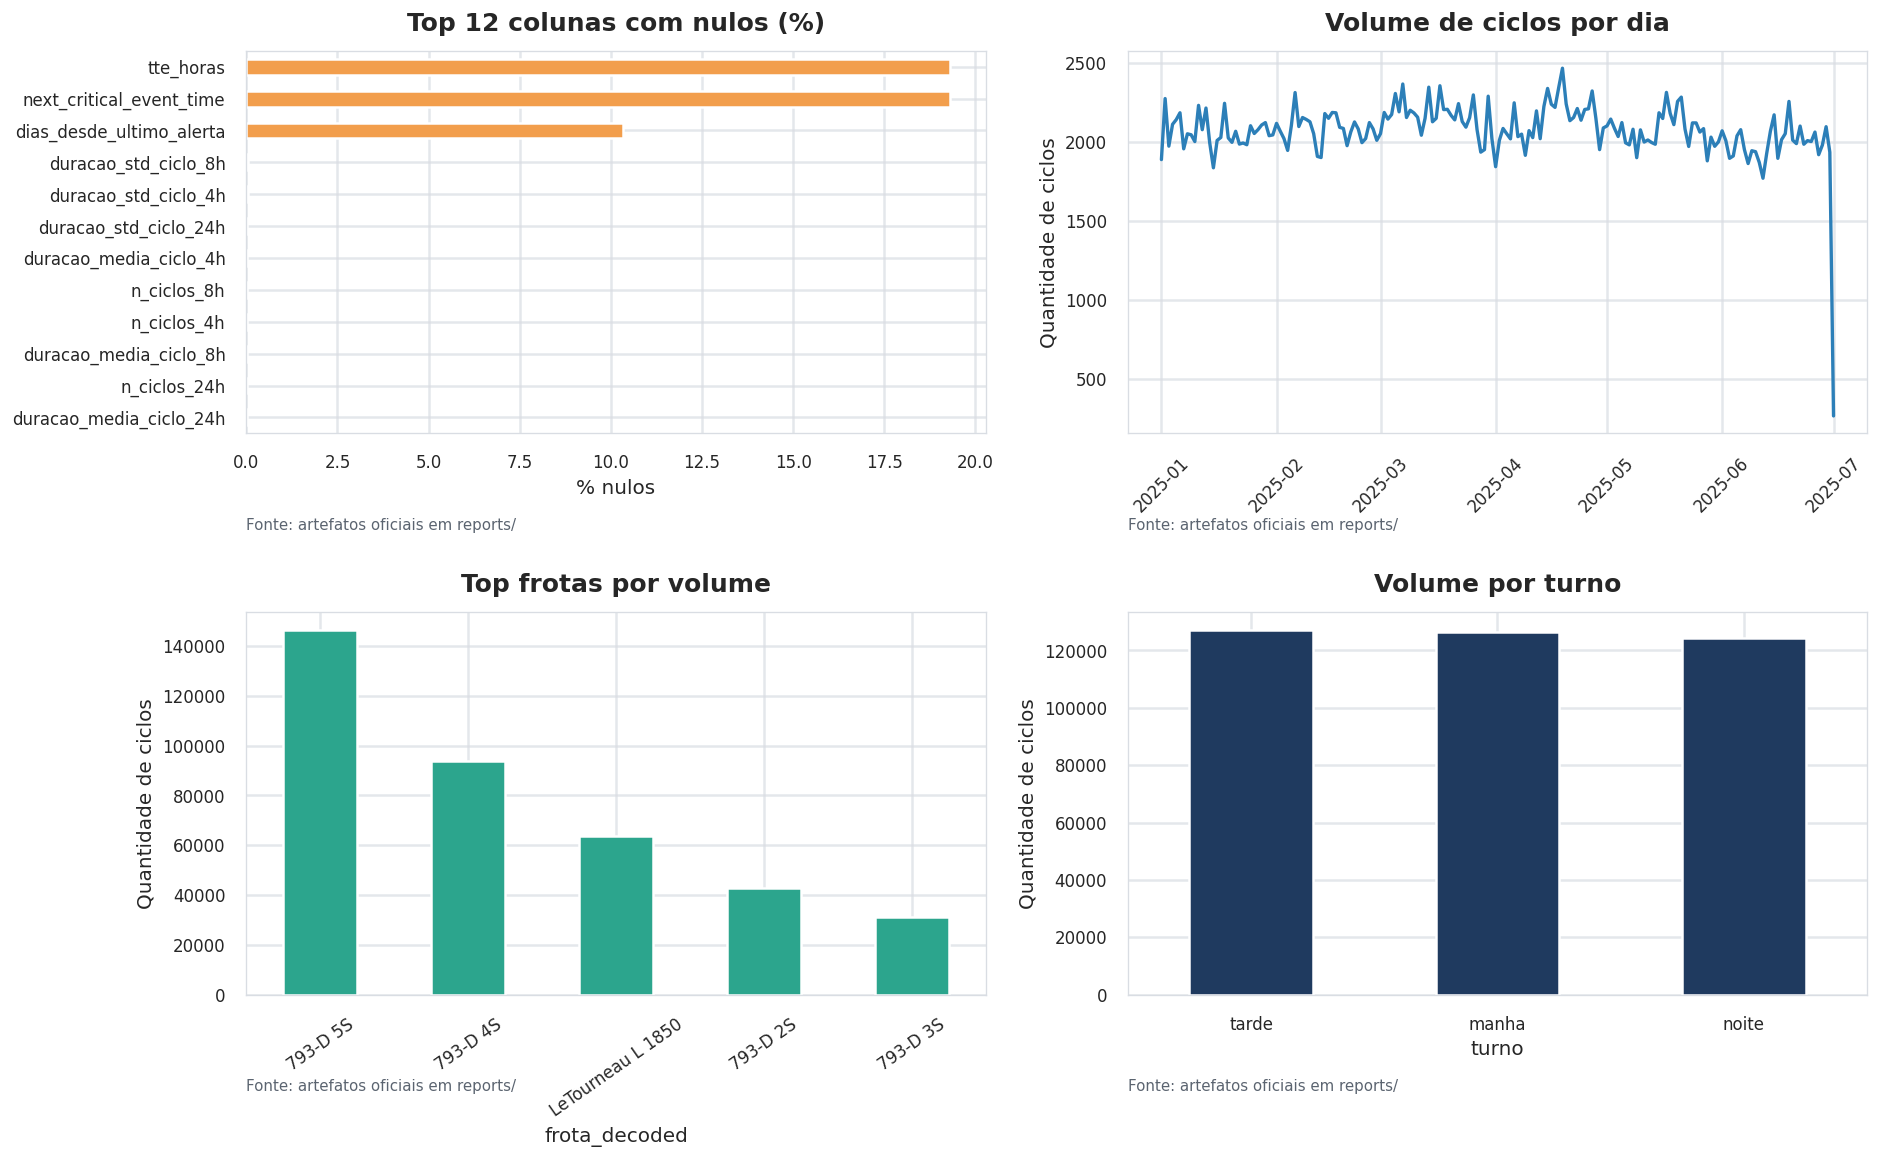

**Insight + implicação operacional:** a cobertura temporal é contínua e os volumes por frota/turno permitem operar um ranking diário com representatividade suficiente.

In [3]:
def decode_one_hot_prefix(df: pd.DataFrame, prefix: str) -> pd.Series:
    cols = [c for c in df.columns if c.startswith(f'{prefix}_')]
    if not cols:
        return pd.Series(['desconhecido'] * len(df), index=df.index)
    matrix = df[cols].fillna(0).astype(int)
    decoded = matrix.idxmax(axis=1).str.replace(f'{prefix}_', '', regex=False)
    decoded.loc[(matrix.sum(axis=1) == 0)] = 'desconhecido'
    return decoded

qc = features_df.copy()
qc['frota_decoded'] = decode_one_hot_prefix(qc, 'Frota')
qc['tipo_decoded'] = decode_one_hot_prefix(qc, 'Tipo')
qc['turno'] = qc['turno'].astype(str)

missing = (qc.isna().mean() * 100).sort_values(ascending=False).head(12)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Missing
ax = axes[0, 0]
missing.sort_values().plot(kind='barh', ax=ax, color=PALETTE['orange'])
ax.set_title('Top 12 colunas com nulos (%)')
ax.set_xlabel('% nulos')
add_source_note(ax)

# Cobertura temporal
ax = axes[0, 1]
vol_dia = qc.groupby(qc['Fim'].dt.date)['Id'].count()
ax.plot(vol_dia.index, vol_dia.values, color=PALETTE['blue'], linewidth=2)
ax.set_title('Volume de ciclos por dia')
ax.set_ylabel('Quantidade de ciclos')
ax.tick_params(axis='x', rotation=45)
add_source_note(ax)

# Volume por frota
ax = axes[1, 0]
qc['frota_decoded'].value_counts().head(8).plot(kind='bar', ax=ax, color=PALETTE['teal'])
ax.set_title('Top frotas por volume')
ax.set_ylabel('Quantidade de ciclos')
ax.tick_params(axis='x', rotation=35)
add_source_note(ax)

# Volume por turno
ax = axes[1, 1]
qc['turno'].value_counts().plot(kind='bar', ax=ax, color=PALETTE['navy'])
ax.set_title('Volume por turno')
ax.set_ylabel('Quantidade de ciclos')
ax.tick_params(axis='x', rotation=0)
add_source_note(ax)

plt.tight_layout()
plt.show()

display(Markdown(
    '**Insight + implicação operacional:** a cobertura temporal é contínua e os volumes por frota/turno permitem operar um ranking diário com representatividade suficiente.'
))

## 3. EDA visual completa

/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_45876/4080567073.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda, x='target_4h', palette=[PALETTE['teal'], PALETTE['red']], ax=ax)


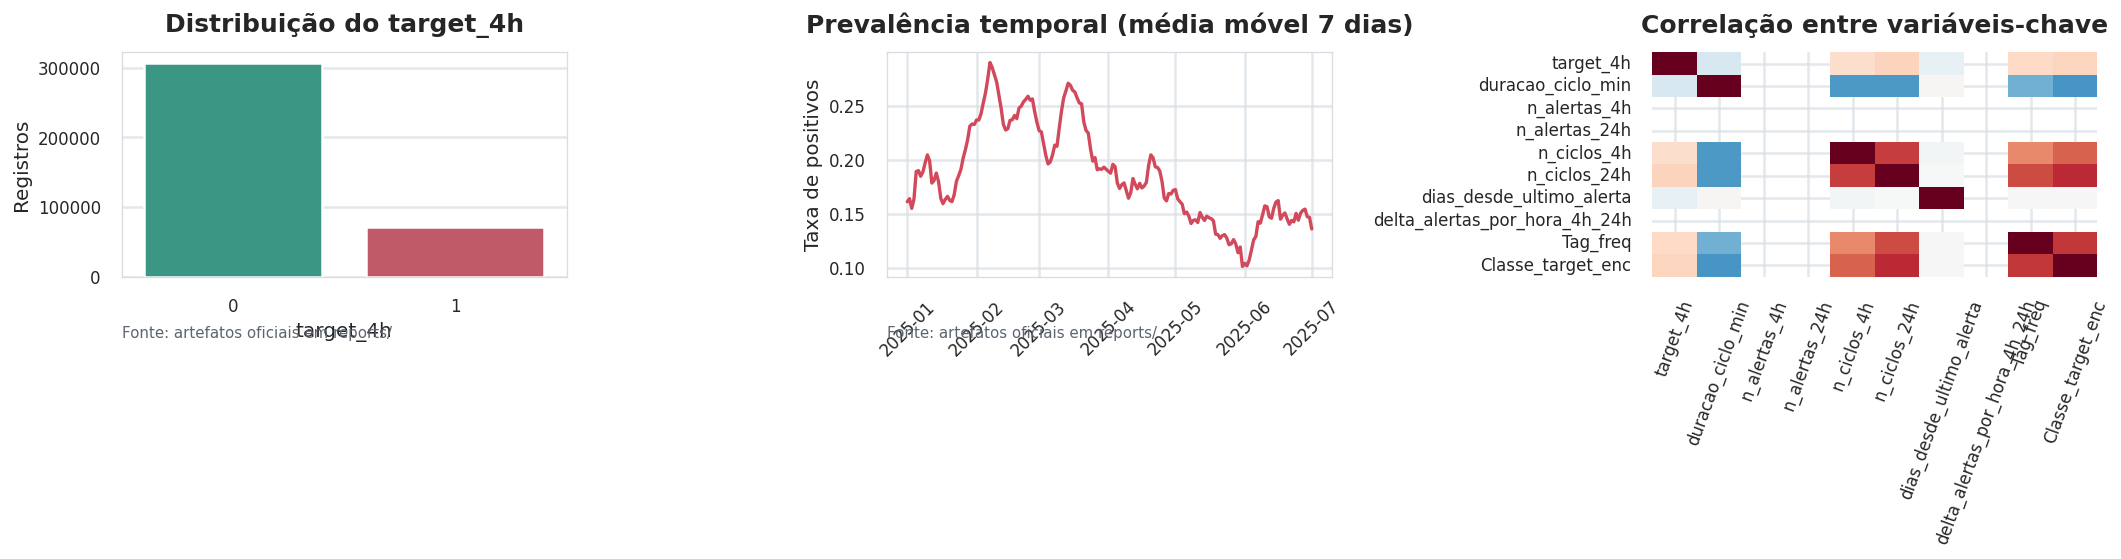

**Insight + implicação operacional:** o target não é aleatório no tempo e há sinais consistentes em histórico de alertas/intensidade operacional, justificando modelagem supervisionada de risco.

In [4]:
eda = features_df.copy()
eda['dia'] = eda['Fim'].dt.date

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribuição target
ax = axes[0]
sns.countplot(data=eda, x='target_4h', palette=[PALETTE['teal'], PALETTE['red']], ax=ax)
ax.set_title('Distribuição do target_4h')
ax.set_xlabel('target_4h')
ax.set_ylabel('Registros')
add_source_note(ax)

# Prevalência temporal
daily_prev = eda.groupby('dia')['target_4h'].mean().rolling(7, min_periods=1).mean()
ax = axes[1]
ax.plot(daily_prev.index, daily_prev.values, color=PALETTE['red'], linewidth=2)
ax.set_title('Prevalência temporal (média móvel 7 dias)')
ax.set_ylabel('Taxa de positivos')
ax.tick_params(axis='x', rotation=45)
add_source_note(ax)

# Heatmap de correlação (subset)
corr_cols = [
    'target_4h', 'duracao_ciclo_min', 'n_alertas_4h', 'n_alertas_24h',
    'n_ciclos_4h', 'n_ciclos_24h', 'dias_desde_ultimo_alerta',
    'delta_alertas_por_hora_4h_24h', 'Tag_freq', 'Classe_target_enc'
]
sub = eda[corr_cols].copy().sample(min(30000, len(eda)), random_state=42)
ax = axes[2]
sns.heatmap(sub.corr(numeric_only=True), cmap='RdBu_r', center=0, ax=ax, cbar=False)
ax.set_title('Correlação entre variáveis-chave')
ax.tick_params(axis='x', rotation=70)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

display(Markdown(
    '**Insight + implicação operacional:** o target não é aleatório no tempo e há sinais consistentes em histórico de alertas/intensidade operacional, justificando modelagem supervisionada de risco.'
))

## 4. Preparação e feature engineering

In [5]:
all_cols = features_df.columns.tolist()

families = {
    'Temporais': [c for c in all_cols if c in {'hora_do_dia','dia_da_semana','mes','turno','is_fim_de_semana','duracao_ciclo_min'}],
    'Alertas rolling': [c for c in all_cols if c.startswith('n_alertas_') or c.startswith('alertas_por_hora_')],
    'Ciclos rolling': [c for c in all_cols if c.startswith('n_ciclos_') or c.startswith('duracao_media_ciclo_') or c.startswith('duracao_std_ciclo_')],
    'Mudança/degradação': [c for c in all_cols if c.startswith('delta_') or c.startswith('ratio_')],
    'Codificação categórica': [c for c in all_cols if c.endswith('_freq') or c.endswith('_target_enc') or c.startswith('Frota_') or c.startswith('Tipo_')],
}

family_df = pd.DataFrame(
    {'Família': list(families.keys()), 'Quantidade de features': [len(v) for v in families.values()]}
).sort_values('Quantidade de features', ascending=False)

display(family_df)

example_cols = [
    'n_alertas_4h', 'n_alertas_24h', 'n_ciclos_4h', 'duracao_media_ciclo_24h',
    'delta_alertas_por_hora_4h_24h', 'Tag_freq', 'Classe_target_enc'
]
display(features_df[example_cols + ['target_4h']].head(8))

display(Markdown(
    '**Insight + implicação operacional:** as features capturam contexto temporal, histórico e mudança de comportamento da operação, o que permite priorização mais robusta por equipamento.'
))

,Família,Quantidade de features
4,Codificação categórica,10
2,Ciclos rolling,9
3,Mudança/degradação,7
0,Temporais,6
1,Alertas rolling,6


,n_alertas_4h,n_alertas_24h,n_ciclos_4h,duracao_media_ciclo_24h,delta_alertas_por_hora_4h_24h,Tag_freq,Classe_target_enc,target_4h
0,0,0,NaN,NaN,0.0,0.008812,0.357143,0
1,0,0,1.0,60.0,0.0,0.008812,0.274510,0
2,0,0,2.0,60.0,0.0,0.008812,0.267606,0
3,0,0,3.0,60.0,0.0,0.008812,0.250000,0
4,0,0,4.0,60.0,0.0,0.008812,0.203252,0
5,0,0,4.0,60.0,0.0,0.008812,0.185430,0
6,0,0,4.0,60.0,0.0,0.008812,0.182692,0
7,0,0,4.0,60.0,0.0,0.008812,0.159363,0


**Insight + implicação operacional:** as features capturam contexto temporal, histórico e mudança de comportamento da operação, o que permite priorização mais robusta por equipamento.

## 5. Benchmark de candidatos

,model_name,val_auc_pr,test_auc_pr,test_recall,test_precision
0,hist_gbdt_regularized,0.288982,0.273617,0.813899,0.270694
1,hist_gbdt_balanced,0.252319,0.287543,0.804829,0.273605
2,lightgbm_balanced,0.249764,0.261005,0.800000,0.270447
3,random_forest_balanced,0.239024,0.243242,0.866196,0.255356
4,logistic_regression_balanced,0.234440,0.244471,0.677032,0.263718
5,extra_trees_balanced,0.223241,0.232324,0.892226,0.250140


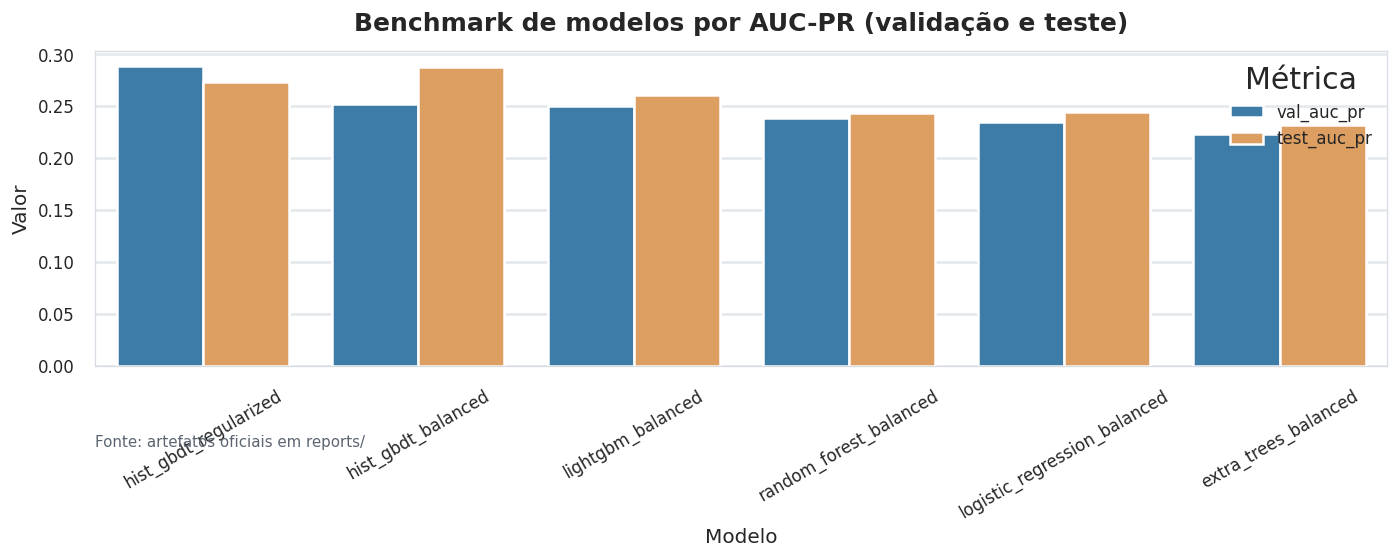

**Insight + implicação operacional:** o campeão foi `hist_gbdt_regularized` por `val_auc_pr=0.2890`; a decisão privilegia generalização (validação) e evita seleção oportunista por teste.

In [6]:
bench = benchmark_df[['model_name','val_auc_pr','test_auc_pr','test_recall','test_precision']].copy()
bench = bench.sort_values('val_auc_pr', ascending=False)

display(bench)

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = bench.melt(id_vars='model_name', value_vars=['val_auc_pr', 'test_auc_pr'], var_name='Métrica', value_name='Valor')
sns.barplot(data=plot_df, x='model_name', y='Valor', hue='Métrica', palette=[PALETTE['blue'], PALETTE['orange']], ax=ax)
ax.set_title('Benchmark de modelos por AUC-PR (validação e teste)')
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=30)
add_source_note(ax)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Insight + implicação operacional:** o campeão foi `{winner_name}` por `val_auc_pr={winner_val_auc_pr:.4f}`; a decisão privilegia generalização (validação) e evita seleção oportunista por teste."
))

## 6. Modelo campeão e threshold operacional

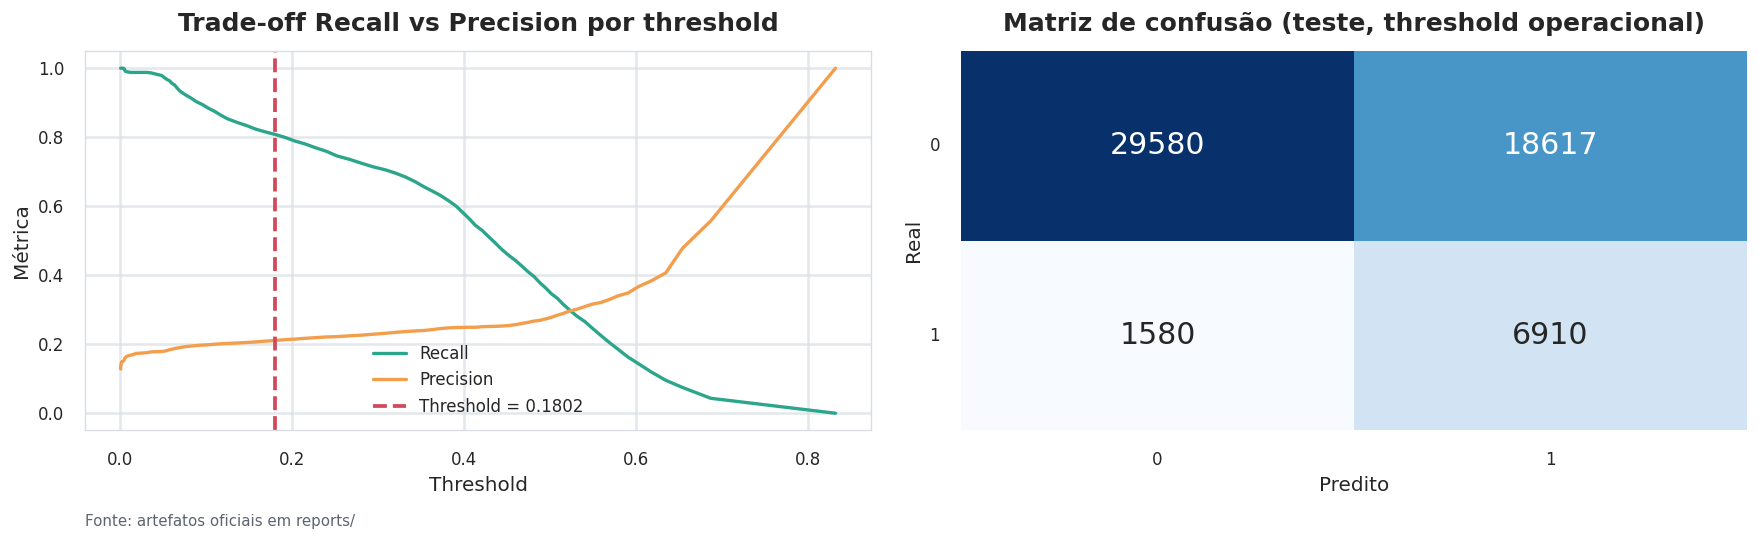

**Insight + implicação operacional:** com threshold `0.1802`, o modelo mantém recall alto (`0.814`) com custo de falso positivo controlado via estratégia de priorização TopK.

In [7]:
threshold = threshold_test['threshold']
curve = threshold_curve_df.copy()
closest_idx = (curve['threshold'] - threshold).abs().idxmin()
selected = curve.loc[closest_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Curva recall/precision
ax = axes[0]
ax.plot(curve['threshold'], curve['recall'], label='Recall', color=PALETTE['teal'], linewidth=2)
ax.plot(curve['threshold'], curve['precision'], label='Precision', color=PALETTE['orange'], linewidth=2)
ax.axvline(threshold, color=PALETTE['red'], linestyle='--', label=f'Threshold = {threshold:.4f}')
ax.set_title('Trade-off Recall vs Precision por threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.legend()
add_source_note(ax)

# Matriz de confusão
ax = axes[1]
rows = int(threshold_test['rows'])
tp = int(threshold_test['true_positive'])
fp = int(threshold_test['false_positive'])
fn = int(threshold_test['false_negative'])
tn = rows - tp - fp - fn
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Matriz de confusão (teste, threshold operacional)')
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

display(Markdown(
    f"**Insight + implicação operacional:** com threshold `{threshold:.4f}`, o modelo mantém recall alto (`{threshold_test['recall']:.3f}`) com custo de falso positivo controlado via estratégia de priorização TopK."
))

## 7. Explicação do modelo

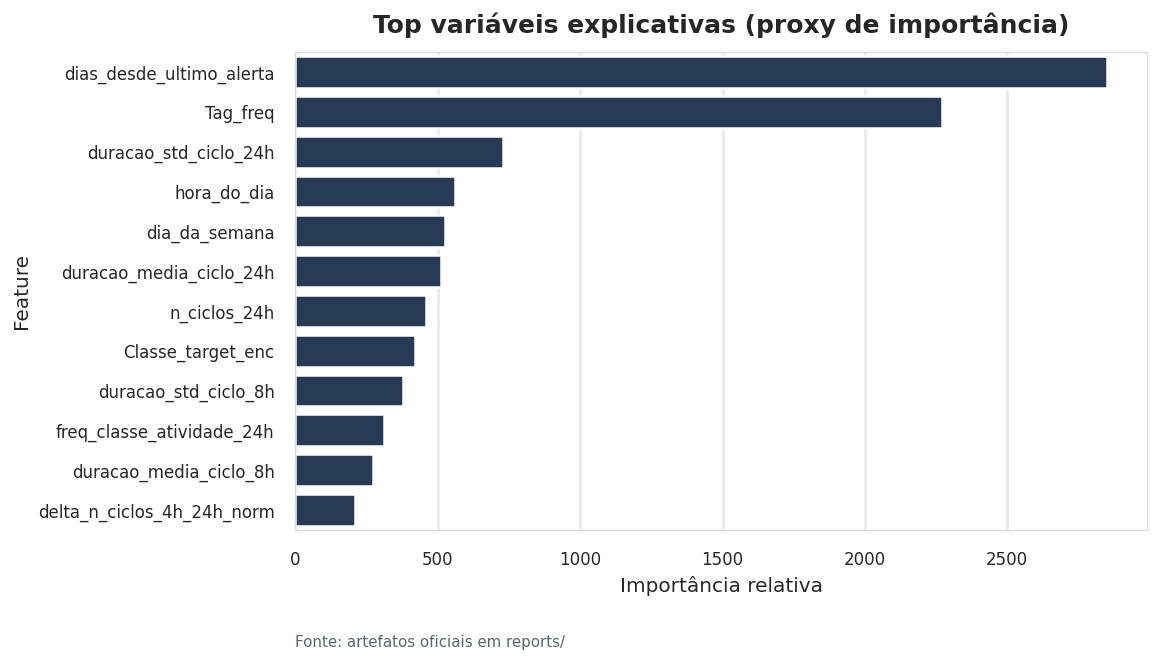

,feature,Leitura de negócio
0,dias_desde_ultimo_alerta,Recência de evento crítico anterior.
1,Tag_freq,Comportamento histórico da tag no conjunto.
2,duracao_std_ciclo_24h,Variável técnica de apoio ao ranking de risco.
3,hora_do_dia,Variável técnica de apoio ao ranking de risco.
4,dia_da_semana,Variável técnica de apoio ao ranking de risco.
5,duracao_media_ciclo_24h,Variável técnica de apoio ao ranking de risco.
6,n_ciclos_24h,Variável técnica de apoio ao ranking de risco.
7,Classe_target_enc,Risco histórico associado à classe de atividade.
8,duracao_std_ciclo_8h,Variável técnica de apoio ao ranking de risco.
9,freq_classe_atividade_24h,Variável técnica de apoio ao ranking de risco.


**Insight + implicação operacional:** os principais sinais estão ligados a histórico e aceleração de alertas; isso permite justificar ações preventivas com base em evidência de comportamento operacional.

In [8]:
imp = feature_importance_df.copy().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp, y='feature', x='importance', color=PALETTE['navy'], ax=ax)
ax.set_title('Top variáveis explicativas (proxy de importância)')
ax.set_xlabel('Importância relativa')
ax.set_ylabel('Feature')
add_source_note(ax)
plt.tight_layout()
plt.show()

business_translation = {
    'n_alertas_24h': 'Histórico recente de alertas críticos do equipamento.',
    'n_alertas_4h': 'Sinal imediato de deterioração no curto prazo.',
    'alertas_por_hora_24h': 'Intensidade normalizada de alertas ao longo do dia.',
    'duracao_ciclo_min': 'Mudança no padrão operacional do ciclo.',
    'dias_desde_ultimo_alerta': 'Recência de evento crítico anterior.',
    'Tag_freq': 'Comportamento histórico da tag no conjunto.',
    'Classe_target_enc': 'Risco histórico associado à classe de atividade.',
}

translation_df = imp[['feature']].copy()
translation_df['Leitura de negócio'] = translation_df['feature'].map(business_translation).fillna(
    'Variável técnica de apoio ao ranking de risco.'
)
display(translation_df)

display(Markdown(
    '**Insight + implicação operacional:** os principais sinais estão ligados a histórico e aceleração de alertas; isso permite justificar ações preventivas com base em evidência de comportamento operacional.'
))

## 8. Avaliação operacional

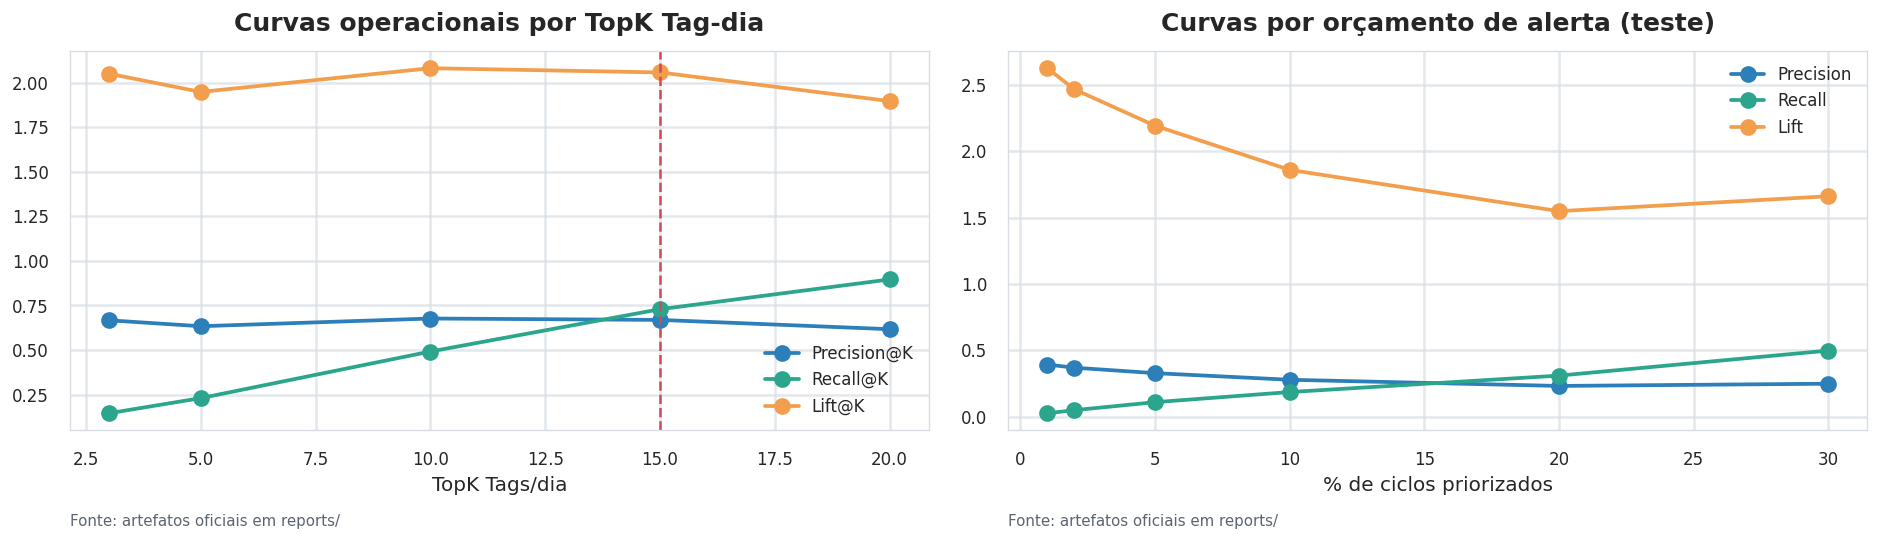

,top_k_tags_per_day,precision_at_k,recall_at_k,lift_vs_random,alerts_per_day
0,3,0.666667,0.145278,2.050040,3.0
1,5,0.633333,0.230024,1.947538,5.0
2,10,0.676667,0.491525,2.080791,10.0
3,15,0.668889,0.728814,2.056874,15.0
4,20,0.616667,0.895884,1.896287,20.0


**Insight + implicação operacional:** Top15 oferece equilíbrio forte entre cobertura e precisão, compatível com rotina diária de priorização sem sobrecarregar a operação.

In [9]:
topk = oper_topk_df.copy().sort_values('top_k_tags_per_day')
budget = oper_budget_df.query("split == 'test'").copy().sort_values('budget_pct')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TopK
ax = axes[0]
ax.plot(topk['top_k_tags_per_day'], topk['precision_at_k'], marker='o', color=PALETTE['blue'], label='Precision@K')
ax.plot(topk['top_k_tags_per_day'], topk['recall_at_k'], marker='o', color=PALETTE['teal'], label='Recall@K')
ax.plot(topk['top_k_tags_per_day'], topk['lift_vs_random'], marker='o', color=PALETTE['orange'], label='Lift@K')
ax.axvline(15, color=PALETTE['red'], linestyle='--', linewidth=1.5)
ax.set_title('Curvas operacionais por TopK Tag-dia')
ax.set_xlabel('TopK Tags/dia')
ax.legend()
add_source_note(ax)

# Budget
ax = axes[1]
ax.plot(budget['budget_pct'] * 100, budget['precision_at_budget'], marker='o', color=PALETTE['blue'], label='Precision')
ax.plot(budget['budget_pct'] * 100, budget['recall_at_budget'], marker='o', color=PALETTE['teal'], label='Recall')
ax.plot(budget['budget_pct'] * 100, budget['lift_vs_random'], marker='o', color=PALETTE['orange'], label='Lift')
ax.set_title('Curvas por orçamento de alerta (teste)')
ax.set_xlabel('% de ciclos priorizados')
ax.legend()
add_source_note(ax)

plt.tight_layout()
plt.show()

display(topk[['top_k_tags_per_day','precision_at_k','recall_at_k','lift_vs_random','alerts_per_day']])

display(Markdown(
    '**Insight + implicação operacional:** Top15 oferece equilíbrio forte entre cobertura e precisão, compatível com rotina diária de priorização sem sobrecarregar a operação.'
))

## 9. Segmentos e riscos

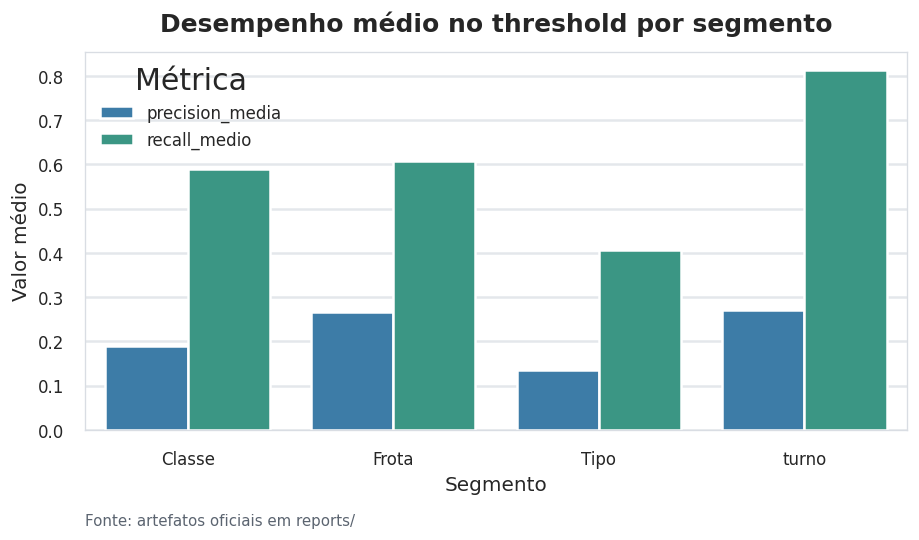

Segmentos fortes (Top15):


,segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
0,turno,manha,15,1185,28,420,15.000000,0.200000,0.450000,0.797468,2.250000,189,237,ok,usar TopK como canal principal
1,turno,tarde,15,1227,29,435,15.000000,0.199674,0.429885,0.763265,2.152935,187,245,ok,usar TopK como canal principal
2,turno,noite,15,1267,30,450,15.000000,0.253354,0.520000,0.728972,2.052461,234,321,ok,usar TopK como canal principal
3,Tipo,Caminhao,15,999,30,450,15.000000,0.411411,0.668889,0.732360,1.625839,301,411,ok,usar TopK como canal principal
4,Classe,Parado,15,784,30,450,15.000000,0.477041,0.637778,0.767380,1.336946,287,374,ok,usar TopK como canal principal
5,Classe,Operando,15,793,30,450,15.000000,0.499369,0.657778,0.747475,1.317217,296,396,ok,usar TopK como canal principal
6,Classe,Manutenção,15,564,30,445,14.833333,0.278369,0.330337,0.936306,1.186689,147,157,ok,usar TopK como canal principal
7,Frota,793-D 5S,15,390,30,390,13.000000,0.597436,0.597436,1.000000,1.000000,233,233,ok,usar TopK como canal principal


Segmentos frágeis (Top15):


,segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
0,Classe,Hibernando,15,400,30,400,13.333333,0.000000,0.000000,0.000000,0.000000,0,0,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
1,turno,noite,15,1267,30,450,15.000000,0.253354,0.520000,0.728972,2.052461,234,321,ok,usar TopK como canal principal
2,Tipo,Caminhao,15,999,30,450,15.000000,0.411411,0.668889,0.732360,1.625839,301,411,ok,usar TopK como canal principal
3,Classe,Operando,15,793,30,450,15.000000,0.499369,0.657778,0.747475,1.317217,296,396,ok,usar TopK como canal principal
4,turno,tarde,15,1227,29,435,15.000000,0.199674,0.429885,0.763265,2.152935,187,245,ok,usar TopK como canal principal
5,Classe,Parado,15,784,30,450,15.000000,0.477041,0.637778,0.767380,1.336946,287,374,ok,usar TopK como canal principal
6,turno,manha,15,1185,28,420,15.000000,0.200000,0.450000,0.797468,2.250000,189,237,ok,usar TopK como canal principal
7,Classe,Manutenção,15,564,30,445,14.833333,0.278369,0.330337,0.936306,1.186689,147,157,ok,usar TopK como canal principal


Segmentos inconclusivos:


,segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
0,Classe,Hibernando,15,400,30,400,13.333333,0.00000,0.00000,0.0,0.0,0,0,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
1,Frota,LeTourneau L 1850,15,271,30,271,9.033333,0.00738,0.00738,1.0,1.0,2,2,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
2,Tipo,Escavadeira,15,271,30,271,9.033333,0.00738,0.00738,1.0,1.0,2,2,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada


Hotspots por Tag:


,Tag,tag_days,avg_score,max_score,positive_days,selected_days,selected_true_positive_days,selected_false_positive_days,missed_positive_days,selected_precision,tag_positive_rate
0,CA65921,30,0.117078,0.173677,25,0,0,0,25,0.000000,0.833333
1,CA5926,30,0.174539,0.222234,18,3,0,3,18,0.000000,0.600000
2,CA65789,30,0.091820,0.124025,14,0,0,0,14,0.000000,0.466667
3,CA65790,30,0.089063,0.109320,13,0,0,0,13,0.000000,0.433333
4,CA65915,30,0.130902,0.187919,10,0,0,0,10,0.000000,0.333333
5,CA65793,30,0.116099,0.161542,9,0,0,0,9,0.000000,0.300000
6,CA65916,30,0.027054,0.038773,9,0,0,0,9,0.000000,0.300000
7,CA65937,30,0.240426,0.327143,15,12,8,4,7,0.666667,0.500000
8,CA65909,30,0.317715,0.491862,18,19,16,3,2,0.842105,0.600000
9,CA65932,30,0.332164,0.398933,18,23,17,6,1,0.739130,0.600000


**Insight + implicação operacional:** há segmentos com desempenho desigual; a governança deve manter exceções para baixa prevalência e criar plano dedicado de mitigação por segmento crítico.

In [10]:
strong = pd.DataFrame(segment_json.get('strongest_top15_segments', []))
weak = pd.DataFrame(segment_json.get('weakest_top15_segments', []))
inconc = pd.DataFrame(segment_json.get('inconclusive_segments', []))

segment_precision = (
    segment_threshold_df.groupby('segment_col', as_index=False)
    .agg(precision_media=('precision', 'mean'), recall_medio=('recall', 'mean'))
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = segment_precision.melt(id_vars='segment_col', value_vars=['precision_media', 'recall_medio'], var_name='Métrica', value_name='Valor')
sns.barplot(data=plot_df, x='segment_col', y='Valor', hue='Métrica', palette=[PALETTE['blue'], PALETTE['teal']], ax=ax)
ax.set_title('Desempenho médio no threshold por segmento')
ax.set_xlabel('Segmento')
ax.set_ylabel('Valor médio')
add_source_note(ax)
plt.tight_layout()
plt.show()

print('Segmentos fortes (Top15):')
display(strong.head(8))

print('Segmentos frágeis (Top15):')
display(weak.head(8))

print('Segmentos inconclusivos:')
display(inconc.head(8))

print('Hotspots por Tag:')
display(segment_hotspots_df.head(10))

display(Markdown(
    '**Insight + implicação operacional:** há segmentos com desempenho desigual; a governança deve manter exceções para baixa prevalência e criar plano dedicado de mitigação por segmento crítico.'
))

## 10. Recomendação executiva

**Decisão recomendada:** avançar com **piloto em shadow mode** com governança ativa.

Condições para avanço controlado:

1. Manter `Top15 Tag-dia` como canal primário de priorização.
2. Revisão semanal de `precision@k`, `recall@k`, `lift@k` e volume de alertas.
3. Preservar gate de estabilidade temporal como bloqueio de promoção.
4. Tratar segmentos inconclusivos em trilha própria (coleta adicional, heurística local ou calibração dedicada).

**Nota técnica curta:** a política de promoção exige campeão por validação, metas operacionais e estabilidade; os artefatos atuais sustentam essa recomendação para piloto controlado.

**Insight + implicação operacional:** o projeto já entrega valor prático para despacho/manutenção, desde que a implantação siga governança com monitoramento contínuo e ajustes segmentados.
